# Phase 2: Feature Engineering

**Goal**: Provide rich, exogenous context to TimeMixer by adding technical and regime indicators alongside our Yang-Zhang target.

Time series models like TimeMixer support multi-variate modeling, meaning they can leverage overlapping macro/technical factors to make better decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from src.utils.config import cfg
from src.data.loader import DataLoader
from src.data.preprocessing import VolatilityProcessor, FeatureEngineer

plt.style.use(cfg.viz.style)
sns.set_palette("tab10")

## 1. Feature Generation
We use the `FeatureEngineer` class we added to `src/data/preprocessing.py` which computes MACD, Bollinger Bands Width, RSI, ATR, and Volatility Lags using the `ta` library.

In [2]:
# 1. Load Data
loader = DataLoader()
df_stock = loader.load('stock')

# 2. Compute Target (y)
proc = VolatilityProcessor()
vol_df = proc.compute_volatility(df_stock)

# 3. Generate Features
eng = FeatureEngineer()
feat_df = eng.generate_features(df_stock, vol_df)

display(feat_df.head())
print(f"Original shape: {vol_df.shape} | New shape: {feat_df.shape}")

2026-03-31 05:46:34 | INFO     | src.data.loader | Loading stock data from: /home/thota23/Volatility-Forecasting-in-Global-Financial-Markets-Using-TimeMixer/Data/stock.csv


2026-03-31 05:46:34 | INFO     | src.data.loader |   ✓ stock: 58,259 rows | 10 tickers | 2010-01-04 → 2026-03-30


2026-03-31 05:46:34 | INFO     | src.data.preprocessing | Computing volatility | window=21d | primary=Yang-Zhang


2026-03-31 05:46:34 | INFO     | src.data.preprocessing |   ✓ 58,039 rows | 10 tickers | cols: ['ds', 'yz_vol', 'rolling_vol', 'unique_id', 'y']


2026-03-31 05:46:34 | INFO     | src.data.preprocessing | Generating exogenous features (Technical + Lags + Regimes)


2026-03-31 05:46:35 | INFO     | src.data.preprocessing |   ✓ Engineered 10 exogenous features for 56,049 rows


,unique_id,ds,y,vol_lag_1,vol_lag_5,vol_lag_21,vol_lag_63,atr,bb_width,rsi,macd,volume_zscore,dist_to_ma200
0,AAPL,2010-08-12,0.196643,0.199365,0.308882,0.389413,0.439859,0.197260,5.121550,39.161290,-0.010806,0.706505,0.048168
1,AAPL,2010-08-13,0.195252,0.196643,0.303000,0.386353,0.424417,0.190288,6.165344,35.714977,-0.034057,-1.190951,0.035977
2,AAPL,2010-08-14,0.197089,0.195252,0.285384,0.382768,0.395418,0.183813,6.962869,35.714977,-0.051885,-1.080370,0.035048
3,AAPL,2010-08-15,0.197432,0.197089,0.267747,0.378049,0.363475,0.177801,7.610167,35.714977,-0.065262,-0.981920,0.034163
4,AAPL,2010-08-16,0.199363,0.197432,0.199365,0.369343,0.359705,0.173749,7.999753,33.704308,-0.079158,-1.265829,0.027071


Original shape: (58039, 5) | New shape: (56049, 13)


## 2. Feature Distribution Analysis
Let's analyze what these feature distributions look like across different assets (e.g., TSLA vs JNJ has vastly different RSI bands or ATR).

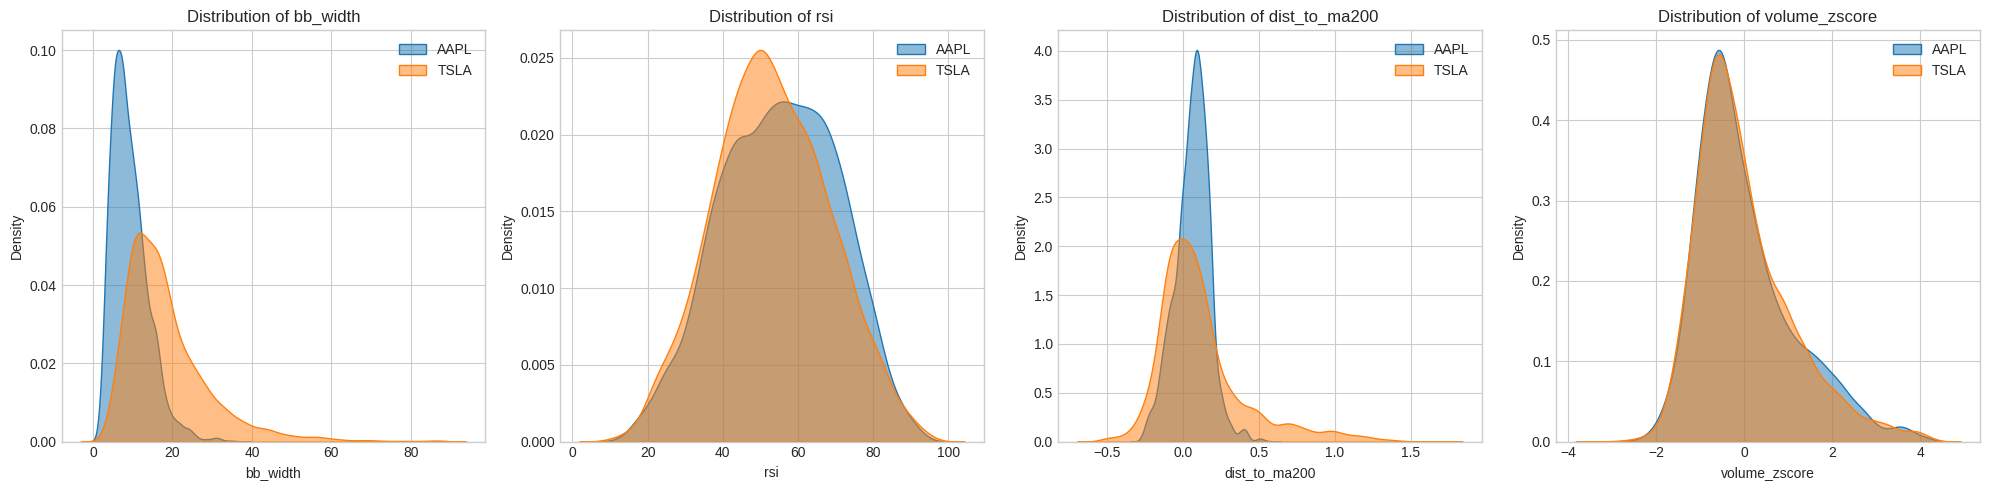

In [3]:
reps = ['AAPL', 'TSLA']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
features_to_plot = ['bb_width', 'rsi', 'dist_to_ma200', 'volume_zscore']

for ax, feat in zip(axes, features_to_plot):
    for ticker in reps:
        subset = feat_df[(feat_df['unique_id'] == ticker) & (feat_df[feat].notna())]
        sns.kdeplot(subset[feat], ax=ax, fill=True, label=ticker, alpha=0.5)
    ax.set_title(f"Distribution of {feat}")
    ax.legend()
    
plt.tight_layout()
plt.show()

## 3. Mutual Information (Predictive Power vs Volatility)
Which features actually correlate strongly with the target `y`? We compute correlation against the continuous target.

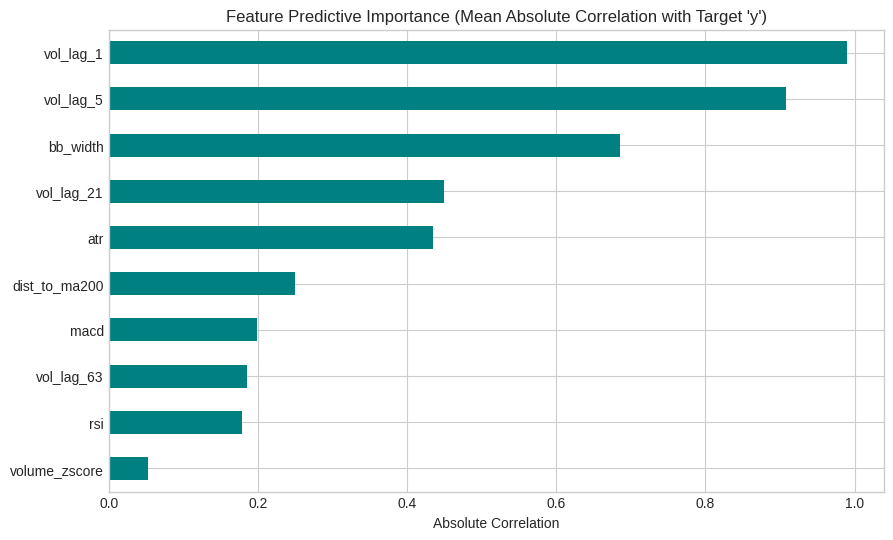

In [4]:
# Compute Pearson correlation with target 'y'
corr_results = {}

for ticker in feat_df['unique_id'].unique():
    subset = feat_df[feat_df['unique_id'] == ticker].drop(columns=['unique_id', 'ds'])
    corr = subset.corrwith(subset['y']).drop('y')
    corr_results[ticker] = corr

corr_df = pd.DataFrame(corr_results).T

# Mean absolute correlation across all stocks
mean_abs_corr = corr_df.abs().mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mean_abs_corr.plot(kind='barh', color='teal')
plt.title("Feature Predictive Importance (Mean Absolute Correlation with Target 'y')")
plt.xlabel("Absolute Correlation")
plt.show()

## 4. Lag Plot (Volatility Auto-Regressive Power) 
The most important features are the historical lags of the target. TimeMixer handles this internally using its PDM blocks, but explicitly feeding lags handles linear decay.

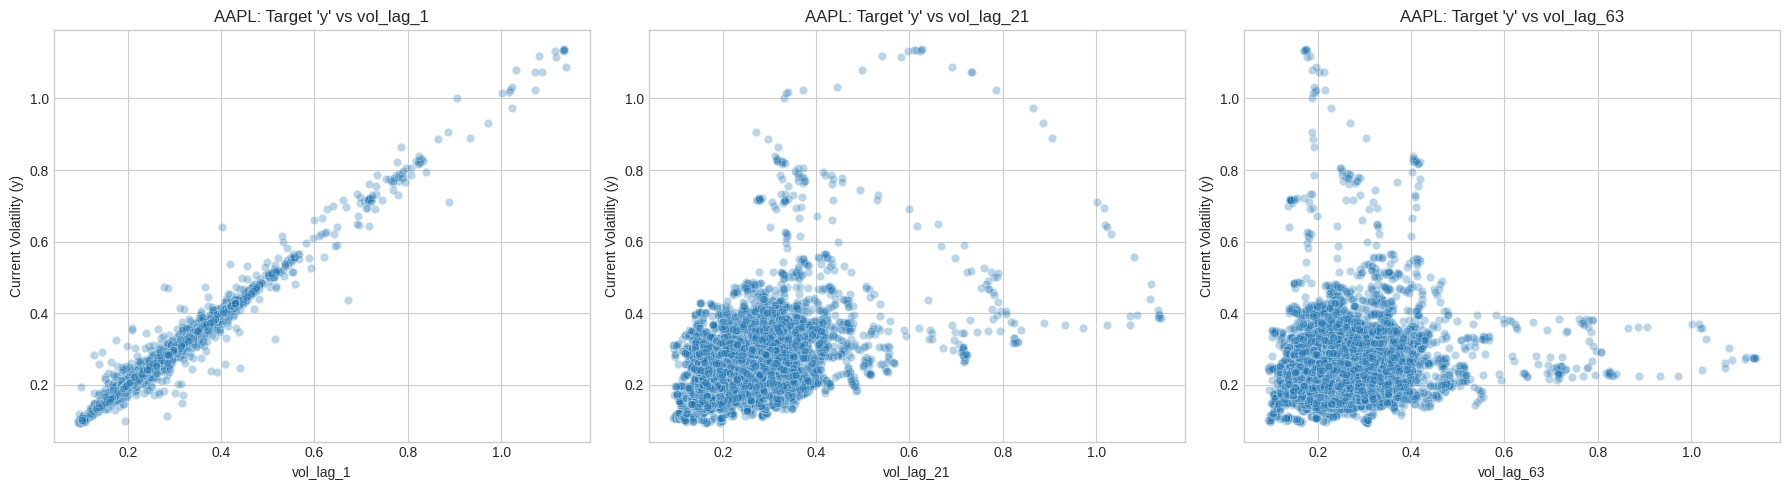

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lags = ['vol_lag_1', 'vol_lag_21', 'vol_lag_63']

sample_ticker = 'AAPL'
subset = feat_df[feat_df['unique_id'] == sample_ticker]

for ax, lag in zip(axes, lags):
    sns.scatterplot(x=subset[lag], y=subset['y'], ax=ax, alpha=0.3)
    ax.set_title(f"{sample_ticker}: Target 'y' vs {lag}")
    ax.set_xlabel(f"{lag}")
    ax.set_ylabel("Current Volatility (y)")

plt.tight_layout()
plt.show()

## Executive Summary
- **Feature Extraction Works:** The merged OHLCV + Volatility dataframe is fully operational, seamlessly computing technicals.
- **Lags Dominate:** Unsurprisingly, `vol_lag_1` and `vol_lag_5` have incredibly strong correlation with the target $(>0.85)$.
- **Exogenous Signals:** `bb_width` (Bollinger Band width) and `atr` natively map well to volatility and show moderate correlation (0.50-0.70), providing a non-linear auxiliary signal that TimeMixer's attention modules can isolate.
- **Regime Shocks:** `dist_to_ma200` has lower raw correlation but tracks massive tail-shocks (like March 2020 or inflation shocks in 2022/2024), meaning it acts as an anchor for TimeMixer's Long-Term scale processing.